# Superstore Sales & Profitability Analysis

## Objective

This notebook explores the Superstore sales dataset to identify key patterns in sales, profitability, and discounting.

The analysis focuses on:

- overall data quality and structure;
- sales and profit performance by category;
- the relationship between discounts and profitability;
- underperforming categories and sub-categories;
- loss-making products and potential drivers of poor profitability.

The goal is to translate the analysis into clear business insights and actionable recommendations.

## 1. Data Loading and Setup

The required Python libraries are imported and the Superstore dataset is loaded into a pandas DataFrame for analysis.

In [1]:
import pandas as pd

In [2]:
file_path = "../data/sample_-_superstore.xls"

df = pd.read_excel(file_path)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_excel("../data/sample_-_superstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 2. Data Overview and Quality Checks

Before conducting the business analysis, the dataset is reviewed to understand its size, structure, data types, and overall data quality.

The review includes checks for missing values, duplicate records, and summary statistics for the key numerical variables.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


## 3. Overall Sales and Profit Performance

This section evaluates the overall financial performance of the Superstore dataset using key business metrics, including total sales, total profit, quantity sold, and overall profit margin.

These metrics provide a high-level view of business performance before examining individual categories, sub-categories, and products in greater detail.

In [9]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)

Total Sales: 2326534.35
Total Profit: 292296.81
Total Quantity Sold: 38654


In [10]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.56 %


## 4. Category Performance Analysis

This section compares sales and profitability across the three product categories: Furniture, Office Supplies, and Technology.

The analysis examines the distribution of transactions across categories, total sales and profit generated by each category, and differences in profit margins. This helps identify which categories contribute most strongly to overall performance and which may require further investigation.

In [11]:
df['Category'].value_counts()

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

In [12]:
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum()

category_performance

,Sales,Profit
Category,,
Furniture,754747.7613,19729.9956
Office Supplies,731893.3140,126023.4434
Technology,839893.2790,146543.3756


In [13]:
category_performance['Profit Margin %'] = (
    category_performance['Profit'] / category_performance['Sales']
) * 100

category_performance.round(2)

,Sales,Profit,Profit Margin %
Category,,,
Furniture,754747.76,19730.00,2.61
Office Supplies,731893.31,126023.44,17.22
Technology,839893.28,146543.38,17.45


## 5. Sub-Category and Discount Analysis

This section examines performance at the sub-category level to identify areas of strong and weak profitability.

Sales, profit, average discount, and profit margin are compared across sub-categories to determine whether discounting patterns may be associated with poor profitability and to identify areas that require deeper investigation.

In [14]:
subcategory_performance = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()

subcategory_performance['Profit Margin %'] = (
    subcategory_performance['Profit'] /
    subcategory_performance['Sales']
) * 100

subcategory_performance.round(2).sort_values('Profit')

,Sales,Profit,Profit Margin %
Sub-Category,,,
Tables,208020.18,-17753.21,-8.53
Bookcases,115361.20,-3632.07,-3.15
Supplies,46725.50,-1171.39,-2.51
Fasteners,8532.24,2428.64,28.46
Machines,189925.03,3461.98,1.82
Labels,12695.04,5572.78,43.90
Art,27659.01,6653.20,24.05
Envelopes,16528.36,6988.02,42.28
Furnishings,95598.13,13891.74,14.53


In [15]:
subcategory_performance.round(2).sort_values('Profit').head(10)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Tables,208020.18,-17753.21,-8.53
Bookcases,115361.20,-3632.07,-3.15
Supplies,46725.50,-1171.39,-2.51
Fasteners,8532.24,2428.64,28.46
Machines,189925.03,3461.98,1.82
Labels,12695.04,5572.78,43.90
Art,27659.01,6653.20,24.05
Envelopes,16528.36,6988.02,42.28
Furnishings,95598.13,13891.74,14.53


## 5. Sub-Category and Discount Analysis

This section examines performance at the sub-category level to identify areas of strong and weak profitability.

Sales, profit, average discount, and profit margin are compared across sub-categories to determine whether discounting patterns may be associated with poor profitability and to identify areas that require deeper investigation.

In [16]:
discount_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
})

discount_analysis['Profit Margin %'] = (
    discount_analysis['Profit'] / discount_analysis['Sales']
) * 100

discount_analysis.sort_values('Profit').round(2)

,Sales,Profit,Discount,Profit Margin %
Sub-Category,,,,
Tables,208020.18,-17753.21,0.26,-8.53
Bookcases,115361.20,-3632.07,0.22,-3.15
Supplies,46725.50,-1171.39,0.08,-2.51
Fasteners,8532.24,2428.64,0.08,28.46
Machines,189925.03,3461.98,0.30,1.82
Labels,12695.04,5572.78,0.07,43.90
Art,27659.01,6653.20,0.08,24.05
Envelopes,16528.36,6988.02,0.08,42.28
Furnishings,95598.13,13891.74,0.14,14.53


In [17]:
loss_makers = discount_analysis[discount_analysis['Profit'] < 0]

loss_makers.round(2)

,Sales,Profit,Discount,Profit Margin %
Sub-Category,,,,
Bookcases,115361.20,-3632.07,0.22,-3.15
Supplies,46725.50,-1171.39,0.08,-2.51
Tables,208020.18,-17753.21,0.26,-8.53


In [18]:
discount_level_analysis = df.groupby('Discount').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
})

discount_level_analysis['Profit Margin %'] = (
    discount_level_analysis['Profit'] /
    discount_level_analysis['Sales']
) * 100

discount_level_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,1105323.79,326718.59,18770,29.56
0.10,54952.50,9099.97,377,16.56
0.15,27558.52,1418.99,198,5.15
0.20,773939.40,91079.95,13856,11.77
0.30,104474.07,-10513.45,855,-10.06
0.32,14493.46,-2391.14,105,-16.50
0.40,116497.76,-23086.37,789,-19.82
0.45,5484.97,-2493.11,45,-45.45
0.50,58918.54,-20506.43,241,-34.80


## 6. Deep Dive: Tables and Discounting

Tables emerged as one of the weakest-performing sub-categories, with substantial sales but an overall loss and a negative profit margin.

This section examines Tables in greater detail by comparing sales, profit, quantity sold, and profit margin across different discount levels. The goal is to determine whether higher discounting is associated with the poor profitability observed in this sub-category.

In [19]:
tables = df[df['Sub-Category'] == 'Tables']

tables_by_discount = tables.groupby('Discount').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
})

tables_by_discount['Profit Margin %'] = (
    tables_by_discount['Profit'] /
    tables_by_discount['Sales']
) * 100

tables_by_discount.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,71706.23,13334.92,323,18.60
0.20,45636.58,-298.40,284,-0.65
0.30,25902.98,-3493.84,184,-13.49
0.40,45614.41,-16187.40,292,-35.49
0.45,5484.97,-2493.11,45,-45.45
0.50,13675.01,-8615.39,133,-63.00


In [20]:
tables_by_region = tables.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
})

tables_by_region['Profit Margin %'] = (
    tables_by_region['Profit'] /
    tables_by_region['Sales']
) * 100

tables_by_region.round(2).sort_values('Profit')

,Sales,Profit,Discount,Profit Margin %
Region,,,,
East,39926.15,-11086.15,0.36,-27.77
South,43916.19,-4623.06,0.22,-10.53
Central,39154.97,-3559.65,0.26,-9.09
West,85022.87,1515.65,0.20,1.78


In [21]:
east_tables = tables[tables['Region'] == 'East']

east_tables_by_state = east_tables.groupby('State/Province').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
})

east_tables_by_state['Profit Margin %'] = (
    east_tables_by_state['Profit'] /
    east_tables_by_state['Sales']
) * 100

east_tables_by_state.round(2).sort_values('Profit')

,Sales,Profit,Discount,Profit Margin %
State/Province,,,,
New York,13779.02,-4535.64,0.40,-32.92
Ohio,7887.11,-2715.33,0.40,-34.43
Pennsylvania,8052.19,-2588.75,0.40,-32.15
Massachusetts,3966.00,-545.29,0.30,-13.75
Rhode Island,1758.25,-230.17,0.30,-13.09
New Hampshire,1053.16,-105.32,0.30,-10.00
Delaware,510.28,-85.90,0.30,-16.83
West Virginia,673.34,-76.95,0.30,-11.43
Maryland,789.80,-71.12,0.30,-9.00


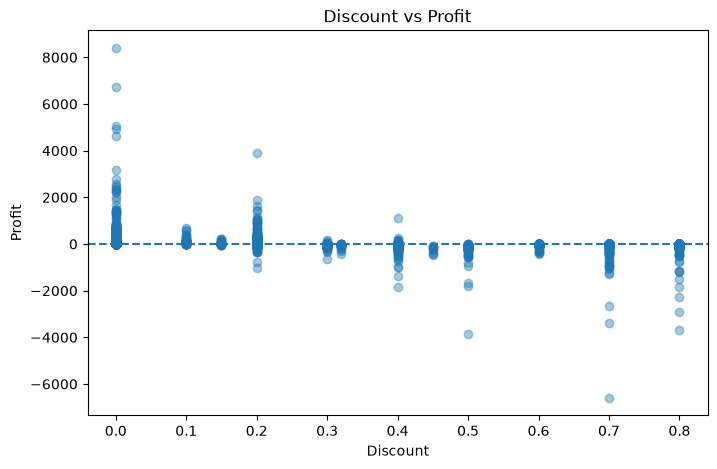

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df['Discount'], df['Profit'], alpha=0.4)

plt.axhline(0, linestyle='--')

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')

plt.show()

In [23]:
import matplotlib
print(matplotlib.__version__)

3.11.1


In [24]:
import matplotlib.pyplot as plt
print("pyplot works")

pyplot works


In [25]:
plt.figure(figsize=(8, 5))
print("figure works")

figure works


<Figure size 800x500 with 0 Axes>

In [26]:
print("kernel test")
2 + 2

kernel test


4

In [27]:
import pandas as pd
import numpy as np

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("imports work")

pandas: 3.0.5
numpy: 2.5.2
imports work


In [28]:
import matplotlib.pyplot as plt
print("matplotlib import works")

matplotlib import works


In [29]:
plt.figure(figsize=(8, 5))
print("figure created")

figure created


<Figure size 800x500 with 0 Axes>

In [30]:
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
print("figure created with Agg")

figure created with Agg


In [31]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.axhline(0, linestyle="--")

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.savefig("discount_vs_profit.png", dpi=150, bbox_inches="tight")
plt.close()

print("Plot saved successfully")

Plot saved successfully


In [32]:
# Measure the relationship between Discount and Profit
correlation = df["Discount"].corr(df["Profit"])

print("Correlation between Discount and Profit:")
print(round(correlation, 3))

Correlation between Discount and Profit:
-0.219


### Insight: Discount vs Profit

The correlation between Discount and Profit is **-0.219**, indicating a weak negative relationship.

The scatter plot also shows that higher discount levels are frequently associated with lower profits and losses. However, the relationship is not strong, suggesting that other factors may also influence profitability.

**Business takeaway:** Discounting should be evaluated carefully, particularly at higher discount levels, because increased discounts are associated with reduced profitability in this dataset.

In [33]:
# Calculate total profit by category
profit_by_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("Total Profit by Category:")
print(profit_by_category)

Total Profit by Category:
Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64


### Insight: Profit by Category

Technology generated the highest total profit at approximately **146,543 dollars**, followed by Office Supplies at approximately **126,023 dollars**.

Furniture generated approximately **19,730 dollars** in total profit, substantially lower than the other two categories.

**Business takeaway:** Technology and Office Supplies are the strongest contributors to overall profit. Furniture should be investigated further to understand why its profitability is significantly lower.

In [34]:
# Calculate total sales by category
sales_by_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("Total Sales by Category:")
print(sales_by_category)

Total Sales by Category:
Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64


In [35]:
# Create bar chart of total sales by category
plt.figure(figsize=(8, 5))

sales_by_category.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=150, bbox_inches="tight")
plt.close()

print("Sales by category chart saved successfully")

Sales by category chart saved successfully


In [36]:
# Calculate sales, profit, and profit margin by category
category_summary = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
})

category_summary["Profit Margin (%)"] = (
    category_summary["Profit"] / category_summary["Sales"] * 100
)

category_summary = category_summary.sort_values(
    "Profit Margin (%)",
    ascending=False
)

print("Category Performance Summary:")
print(category_summary.round(2))

Category Performance Summary:
                     Sales     Profit  Profit Margin (%)
Category                                                
Technology       839893.28  146543.38              17.45
Office Supplies  731893.31  126023.44              17.22
Furniture        754747.76   19730.00               2.61


In [37]:
# Create profit margin by category chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_summary.index,
    category_summary["Profit Margin (%)"]
)

plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Category")

plt.tight_layout()
plt.savefig("profit_margin_by_category.png", dpi=150, bbox_inches="tight")
plt.close()

print("Profit margin chart saved successfully")

Profit margin chart saved successfully


### Insight: Profit Margin by Category

Technology has the highest profit margin at approximately **17.45%**, closely followed by Office Supplies at **17.22%**.

Furniture has a profit margin of only **2.61%**, despite generating approximately **$754,748** in sales. This shows that Furniture converts a much smaller proportion of its sales into profit than the other categories.

**Business takeaway:** Furniture should be investigated further to identify the factors reducing profitability. Potential areas for further analysis include discount levels, individual sub-categories, and products generating losses.

In [38]:
# Analyze Furniture performance by sub-category
furniture_df = df[df["Category"] == "Furniture"]

furniture_summary = furniture_df.groupby("Sub-Category").agg({
    "Sales": "sum",
    "Profit": "sum"
})

furniture_summary["Profit Margin (%)"] = (
    furniture_summary["Profit"] / furniture_summary["Sales"] * 100
)

furniture_summary = furniture_summary.sort_values(
    "Profit",
    ascending=False
)

print("Furniture Performance by Sub-Category:")
print(furniture_summary.round(2))

Furniture Performance by Sub-Category:
                  Sales    Profit  Profit Margin (%)
Sub-Category                                        
Chairs        335768.25  27223.53               8.11
Furnishings    95598.13  13891.74              14.53
Bookcases     115361.20  -3632.07              -3.15
Tables        208020.18 -17753.21              -8.53


In [39]:
# Create Furniture profit by sub-category chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    furniture_summary.index,
    furniture_summary["Profit"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Furniture Sub-Category")
plt.ylabel("Total Profit")
plt.title("Furniture Profit by Sub-Category")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "furniture_profit_by_subcategory.png",
    dpi=150,
    bbox_inches="tight"
)
plt.close()

print("Furniture sub-category chart saved successfully")

Furniture sub-category chart saved successfully


### Insight: Furniture Profit by Sub-Category

Chairs generated the highest profit within Furniture at approximately **27,224 dollars**, followed by Furnishings at approximately **13,892 dollars**.

However, Bookcases generated a loss of approximately **3,632 dollars**, while Tables produced the largest loss at approximately **17,753 dollars** despite generating more than **208,000 dollars in sales**.

Tables also had the lowest profit margin at **-8.53%**, compared with **-3.15%** for Bookcases.

**Business takeaway:** The low profitability of the Furniture category is largely driven by losses from Tables and Bookcases. These sub-categories should be examined further, particularly for discounting and loss-making products.

In [40]:
# Analyze discount and profit for Furniture sub-categories
discount_analysis = (
    furniture_df
    .groupby("Sub-Category")
    .agg({
        "Discount": "mean",
        "Sales": "sum",
        "Profit": "sum"
    })
)

discount_analysis["Average Discount (%)"] = (
    discount_analysis["Discount"] * 100
)

discount_analysis = discount_analysis[
    ["Average Discount (%)", "Sales", "Profit"]
].sort_values("Average Discount (%)", ascending=False)

print("Furniture Discount Analysis:")
print(discount_analysis.round(2))

Furniture Discount Analysis:
              Average Discount (%)      Sales    Profit
Sub-Category                                           
Tables                       25.81  208020.18 -17753.21
Bookcases                    21.53  115361.20  -3632.07
Chairs                       16.92  335768.25  27223.53
Furnishings                  13.81   95598.13  13891.74


In [41]:
# Create average discount by Furniture sub-category chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    discount_analysis.index,
    discount_analysis["Average Discount (%)"]
)

plt.xlabel("Furniture Sub-Category")
plt.ylabel("Average Discount (%)")
plt.title("Average Discount by Furniture Sub-Category")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "furniture_discount_by_subcategory.png",
    dpi=150,
    bbox_inches="tight"
)
plt.close()

print("Furniture discount chart saved successfully")

Furniture discount chart saved successfully


### Insight: Furniture Discounts and Profitability

Tables had the highest average discount at approximately **25.81%** and generated the largest loss of approximately **17,753 dollars**.

Bookcases had the second-highest average discount at approximately **21.53%** and also generated a loss of approximately **3,632 dollars**.

In comparison, Chairs and Furnishings had lower average discounts of approximately **16.92%** and **13.81%**, respectively, and both generated positive profits.

**Business takeaway:** Higher discount levels are associated with weaker profitability within the Furniture category. Tables and Bookcases should be examined more closely to determine whether discounting, product costs, or other factors are contributing to their losses.

In [42]:
# Find the biggest loss-making products in Furniture

furniture_products = (
    df[df["Category"] == "Furniture"]
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean")
    )
)

furniture_products["Profit Margin (%)"] = (
    furniture_products["Profit"] / furniture_products["Sales"] * 100
)

furniture_products = furniture_products.sort_values("Profit")

print("Top 10 Loss-Making Furniture Products:")
print(furniture_products.head(10).round(2))

Top 10 Loss-Making Furniture Products:
                                                      Sales   Profit  \
Product Name                                                           
Chromcraft Bull-Nose Wood Oval Conference Table...  9917.64 -2876.12   
Bush Advantage Collection Racetrack Conference ...  9544.72 -1934.40   
Balt Solid Wood Round Tables                        6518.75 -1201.06   
BoxOffice By Design Rectangular and Half-Moon M...  1706.25 -1148.44   
Riverside Furniture Oval Coffee Table, Oval End...  4446.18 -1147.40   
Hon 2090 “Pillow Soft” Series Mid Back Swivel/T...  5282.42  -989.05   
O'Sullivan 4-Shelf Bookcase in Odessa Pine          2740.20  -975.10   
Bretford “Just In Time” Height-Adjustable Multi...  5634.90  -964.19   
Bevis Oval Conference Table, Walnut                 6942.07  -856.01   
BPI Conference Tables                               2241.87  -795.97   

                                                    Average_Discount  \
Product Name            

In [43]:
# Plot the 10 biggest loss-making Furniture products

top_10_losses = furniture_products.head(10).sort_values("Profit")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_losses.index,
    top_10_losses["Profit"]
)

plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.title("Top 10 Loss-Making Furniture Products")

plt.tight_layout()

plt.savefig(
    "top_10_loss_furniture_products.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Top 10 loss-making Furniture products chart saved successfully")

Top 10 loss-making Furniture products chart saved successfully


### Insight: Loss-Making Furniture Products

The product-level analysis shows that Furniture losses are concentrated among a relatively small group of individual products rather than being evenly distributed across the category.

Several of the largest loss-making products are Tables and Bookcases, which is consistent with the earlier sub-category analysis showing that these two areas generated overall losses.

Some of these products also have substantial average discounts and strongly negative profit margins, indicating that discounting may be one factor associated with poor product-level profitability.

**Business takeaway:** Management should review the highest loss-making Furniture products individually, particularly Tables and Bookcases. Pricing, discount levels, product costs, and continued product viability should be evaluated before making broader changes across the entire Furniture category.

# Final Conclusions and Recommendations

The analysis shows that the Superstore is profitable overall, generating approximately **$2.33 million in sales** and **$292,297 in profit**, with an overall profit margin of approximately **12.56%**.

However, profitability varies substantially across product categories. **Technology** and **Office Supplies** achieve profit margins of approximately **17.45%** and **17.22%**, respectively, while **Furniture** generates a much lower profit margin of approximately **2.61%**.

Further analysis of Furniture shows that **Tables** and **Bookcases** are the primary loss-making sub-categories. Tables generated a loss of approximately **$17,753**, while Bookcases generated a loss of approximately **$3,632**. These sub-categories also have relatively high average discount levels, suggesting that discounting may be associated with their weaker profitability.

Product-level analysis further shows that Furniture losses are concentrated among a relatively small number of products, particularly within Tables and Bookcases.

## Recommendations

1. **Review discounting strategies for Tables and Bookcases.** Evaluate whether current discount levels can be reduced without significantly affecting sales volume.

2. **Investigate the highest loss-making Furniture products individually.** Review their pricing, product costs, discount levels, and sales performance.

3. **Monitor profit margin alongside sales.** High sales do not necessarily translate into strong profitability, as demonstrated by the Furniture category.

4. **Use targeted rather than category-wide changes.** Because losses are concentrated in specific sub-categories and products, management should prioritize those areas before making broader changes across Furniture.

5. **Continue monitoring the relationship between discounts and profitability.** Discounting appears to be associated with weaker profitability in several areas, but other factors such as product costs and pricing should also be considered.

## Final Business Takeaway

The Superstore is profitable overall, but there is a clear opportunity to improve profitability by addressing underperforming Furniture products. A more targeted approach to discounting, pricing, and product-level performance management—particularly for Tables and Bookcases—could help reduce losses while protecting sales.